# RandomForestRegressor

OSD.longitude:
Mean Squared Error: 1.4264920318266782e-10
R^2 Score: 0.7098412087469077

OSD.latitude:
Mean Squared Error: 3.478891328158401e-10
R^2 Score: 0.7895546058091608

OSD.height [ft]:
Mean Squared Error: 542.3468247679194
R^2 Score: 0.44232055937606485

OSD.pitch:
Mean Squared Error: 2.78599028305173
R^2 Score: 0.6051195335331748

OSD.roll:
Mean Squared Error: 1.6005515371268713
R^2 Score: 0.3759465303691547

OSD.yaw:
Mean Squared Error: 2207.310318418475
R^2 Score: 0.6891978617039429



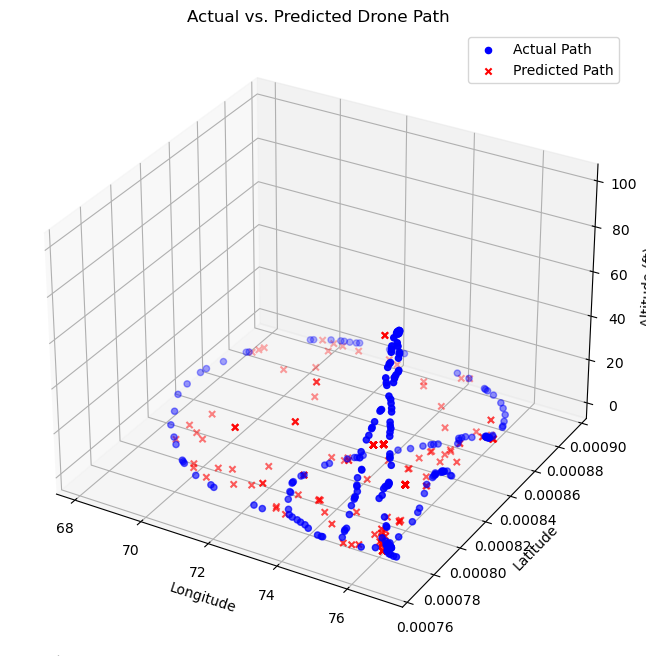

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'your_file.csv' is the name of your CSV file
df = pd.read_csv('training/dataset_10.csv')

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df[input_features], df[targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Handling missing values in target variables (if any)
y_train = y_train.dropna().reset_index(drop=True)
X_train_imputed = X_train_imputed[y_train.index]

# Creating and training the Random Forest Regression models
models = {}
for target_variable in targets:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_imputed, y_train[target_variable])
    models[target_variable] = model

# Making predictions on the test set
predictions = {}
for target_variable, model in models.items():
    predictions[target_variable] = model.predict(X_test_imputed)

# Calculate and print the accuracy metrics
for target_variable in targets:
    mse = mean_squared_error(y_test[target_variable], predictions[target_variable])
    r2 = r2_score(y_test[target_variable], predictions[target_variable])
    print(f"{target_variable}:")
    print(f"Mean Squared Error: {mse}")
    print(f"R^2 Score: {r2}")
    print()

# Create a 3D plot for the predicted drone path
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual drone path
ax.scatter(y_test['OSD.longitude'], y_test['OSD.latitude'], y_test['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')

# Plot the predicted drone path
ax.scatter(predictions['OSD.longitude'], predictions['OSD.latitude'], predictions['OSD.height [ft]'], c='red', marker='x', label='Predicted Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('Actual vs. Predicted Drone Path')
ax.legend()

# Show the plot
plt.show()


OSD.longitude:
Mean Squared Error: 0.0020105625539807172
R^2 Score: -8589344.895222684

OSD.latitude:
Mean Squared Error: 0.0029359719750654215
R^2 Score: -4689757.256963346

OSD.height [ft]:
Mean Squared Error: 72.14623686787894
R^2 Score: -123.8047039725115

OSD.pitch:
Mean Squared Error: 3.479263939875588
R^2 Score: 0.31110915521671

OSD.roll:
Mean Squared Error: 0.9978524873128511
R^2 Score: -0.15407342615221142

OSD.yaw:
Mean Squared Error: 6826.237589613615
R^2 Score: 0.12334319686724948



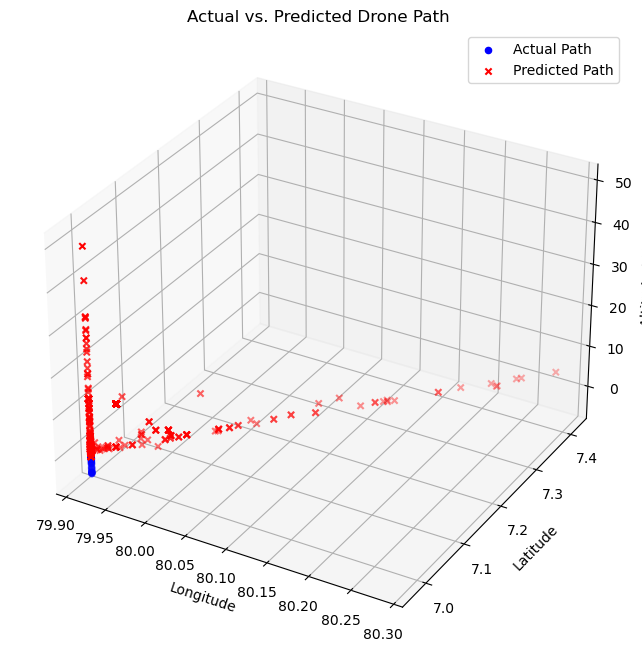

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

# Function to read all CSV files from a directory and concatenate them into a single DataFrame
def read_multiple_csv(directory):
    all_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.csv')]
    return pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# Read multiple CSV files from the 'training' folder
training_df = read_multiple_csv('training')

# Read a CSV file from the 'testing' folder
testing_df = pd.read_csv('testing/dataset_05.csv')

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Handling missing values in input features using SimpleImputer for training data
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(training_df[input_features])

# Handling missing values in target variables (if any) for training data
y_train = training_df[targets].dropna()
X_train_imputed = X_imputed[y_train.index]

# Creating and training the Random Forest Regression models
models = {}
for target_variable in targets:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_imputed, y_train[target_variable])
    models[target_variable] = model

# Handling missing values in input features for testing data
X_test_imputed = imputer.transform(testing_df[input_features])

# Making predictions on the test set
predictions = {}
for target_variable, model in models.items():
    predictions[target_variable] = model.predict(X_test_imputed)

# Calculate and print the accuracy metrics
for target_variable in targets:
    mse = mean_squared_error(testing_df[target_variable], predictions[target_variable])
    r2 = r2_score(testing_df[target_variable], predictions[target_variable])
    print(f"{target_variable}:")
    print(f"Mean Squared Error: {mse}")
    print(f"R^2 Score: {r2}")
    print()

# Create a 3D plot for the predicted drone path
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual drone path
ax.scatter(testing_df['OSD.longitude'], testing_df['OSD.latitude'], testing_df['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')

# Plot the predicted drone path
ax.scatter(predictions['OSD.longitude'], predictions['OSD.latitude'], predictions['OSD.height [ft]'], c='red', marker='x', label='Predicted Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('Actual vs. Predicted Drone Path')
ax.legend()

# Show the plot
plt.show()


OSD.longitude:
Mean Squared Error: 0.00196484339635607
R^2 Score: -8394027.590571407

OSD.latitude:
Mean Squared Error: 0.0029804998965857615
R^2 Score: -4760883.680985421

OSD.height [ft]:
Mean Squared Error: 157.62454265787972
R^2 Score: -271.67235602662066

OSD.pitch:
Mean Squared Error: 3.7954881931934046
R^2 Score: 0.24849706347156197

OSD.roll:
Mean Squared Error: 1.2425162418171272
R^2 Score: -0.43704104010924993

OSD.yaw:
Mean Squared Error: 9407.002705277278
R^2 Score: -0.2080905199105887



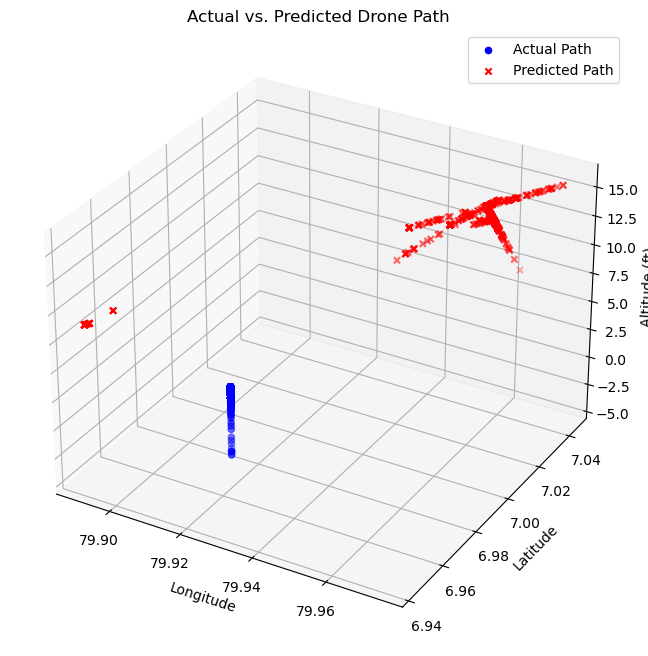

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

# Function to read all CSV files from a directory and concatenate them into a single DataFrame
def read_multiple_csv(directory):
    all_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.csv')]
    return pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# Read multiple CSV files from the 'training' folder
training_df = read_multiple_csv('training')

# Read a CSV file from the 'testing' folder
testing_df = pd.read_csv('testing/dataset_05.csv')

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Feature Engineering
imputer = SimpleImputer(strategy='mean') 
scaler = StandardScaler()
poly_features = PolynomialFeatures(degree=2)

# Handling missing values in input features for training data
X_imputed = imputer.fit_transform(training_df[input_features])
X_scaled = scaler.fit_transform(X_imputed)
X_poly = poly_features.fit_transform(X_scaled)

# Handling missing values in target variables (if any) for training data
y_train = training_df[targets].dropna()
X_train_imputed = X_imputed[y_train.index]
X_train_scaled = X_scaled[y_train.index]
X_train_poly = X_poly[y_train.index]

# Creating and training the Linear Regression models
models = {}
for i, target_variable in enumerate(targets):
    model = LinearRegression()
    if i < len(targets) - 1:
        model.fit(X_train_imputed, y_train[target_variable])
    else:
        model.fit(X_train_poly, y_train[target_variable])
    models[target_variable] = model

# Handling missing values in input features for testing data
X_test_imputed = imputer.transform(testing_df[input_features])
X_test_scaled = scaler.transform(X_test_imputed)
X_test_poly = poly_features.transform(X_test_scaled)

# Making predictions on the test set
predictions = {}
for target_variable, model in models.items():
    if target_variable != 'OSD.yaw':
        predictions[target_variable] = model.predict(X_test_imputed)
    else:
        predictions[target_variable] = model.predict(X_test_poly)

# Calculate and print the accuracy metrics
for target_variable in targets:
    mse = mean_squared_error(testing_df[target_variable], predictions[target_variable])
    r2 = r2_score(testing_df[target_variable], predictions[target_variable])
    print(f"{target_variable}:")
    print(f"Mean Squared Error: {mse}")
    print(f"R^2 Score: {r2}")
    print()

# Create a 3D plot for the predicted drone path
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual drone path
ax.scatter(testing_df['OSD.longitude'], testing_df['OSD.latitude'], testing_df['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')

# Plot the predicted drone path
ax.scatter(predictions['OSD.longitude'], predictions['OSD.latitude'], predictions['OSD.height [ft]'], c='red', marker='x', label='Predicted Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('Actual vs. Predicted Drone Path')
ax.legend()

# Show the plot
plt.show()
